# GAN - ArtBench

## Imports

In [ ]:
from __future__ import annotations

import sys
import csv
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms 
from torchvision.utils import make_grid
import torchvision.utils as vutils

import json

from pathlib import Path


In [35]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

import random
'''
seed = random.randint(0, 500)
set_seed(seed)
print(f"Using seed: {seed}")'''

seed=71
set_seed(seed)

In [ ]:
IMAGE_SIZE = 32
BATCH_SIZE = 64


nc = 3

nz = 100

ngf = 64

ndf = 64

num_epochs = 50

lr_G = 2e-4
lr_D = 1e-4
assert lr_G >= lr_D, f"Invalid setup: lr_G ({lr_G}) must be >= lr_D ({lr_D})"

beta1 = 0.5

ngpu = 1

In [37]:
DEVIDE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVIDE)


Device: cuda


## Dataset

In [ ]:
def find_project_root(start: Path, markers: list[str], max_levels: int = 6) -> Path:

    path = start
    for _ in range(max_levels):
        if all((path / m).exists() for m in markers):
            return path
        path = path.parent
    raise RuntimeError(
        f"PROJECT_ROOT não encontrado a partir de {start}.\n"
        "Estrutura esperada: pasta com 'ArtBench-10/' e 'TP1-alunos-src-only/'."
    )

PROJECT_ROOT      = find_project_root(Path(".").resolve(), ["ArtBench-10", "TP1-alunos-src-only"])
SCRIPTS_DIR       = PROJECT_ROOT / "TP1-alunos-src-only" / "scripts"
KAGGLE_ROOT       = PROJECT_ROOT / "ArtBench-10"
TRAINING_CSV_PATH = PROJECT_ROOT / "TP1-alunos-src-only" / "student_start_pack" / "training_20_percent.csv"

print("PROJECT_ROOT   =", PROJECT_ROOT)
print("SCRIPTS_DIR    =", SCRIPTS_DIR)
print("KAGGLE_ROOT    =", KAGGLE_ROOT)
print("TRAINING CSV   =", TRAINING_CSV_PATH)

assert SCRIPTS_DIR.exists(), f"Não existe: {SCRIPTS_DIR}"
assert KAGGLE_ROOT.exists(), f"Não existe: {KAGGLE_ROOT}"
assert TRAINING_CSV_PATH.exists(), f"Não existe: {TRAINING_CSV_PATH}"

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))


PROJECT_ROOT   = D:\MESTRADO\1º Ano\2º Semestre\IAG\IAG_TP1
SCRIPTS_DIR    = D:\MESTRADO\1º Ano\2º Semestre\IAG\IAG_TP1\TP1-alunos-src-only\scripts
KAGGLE_ROOT    = D:\MESTRADO\1º Ano\2º Semestre\IAG\IAG_TP1\ArtBench-10
TRAINING CSV   = D:\MESTRADO\1º Ano\2º Semestre\IAG\IAG_TP1\TP1-alunos-src-only\student_start_pack\training_20_percent.csv


In [39]:
from artbench_local_dataset import load_kaggle_artbench10_splits

hf_ds = load_kaggle_artbench10_splits(KAGGLE_ROOT)
train_dataset_completo = hf_ds["train"]

print("Número total de imagens de treino:", len(train_dataset_completo))
print("Colunas:", train_dataset_completo.column_names)

label_feature = train_dataset_completo.features["label"]
class_names = list(label_feature.names)
num_classes = len(class_names)

print("Número de classes:", num_classes)
print("Classes:", class_names)

Dataset source: kaggle root='D:\MESTRADO\1º Ano\2º Semestre\IAG\IAG_TP1\ArtBench-10'
Número total de imagens de treino: 50000
Colunas: ['image', 'label']
Número de classes: 10
Classes: ['impressionism', 'realism', 'romanticism', 'expressionism', 'baroque', 'post_impressionism', 'art_nouveau', 'surrealism', 'ukiyo_e', 'renaissance']


In [ ]:
transform=transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        ex = self.ds[real_idx]
        img = ex["image"]
        y = int(ex["label"])
        x = self.transform(img) if self.transform is not None else img
        return x, y, real_idx

def denorm(x):
    
    return (x * 0.5 + 0.5).clamp(0, 1)

In [41]:
INDEX_COLUMN = "train_id_original"

def load_ids_from_training_csv(csv_path: Path, index_column: str = "train_id_original") -> list[int]:
    ids = []
    with open(csv_path, "r", encoding="utf-8", newline="") as f:
        reader = csv.DictReader(f)
        if index_column not in (reader.fieldnames or []):
            raise ValueError(f"Coluna {index_column!r} não encontrada. Disponíveis: {reader.fieldnames}")
        for row in reader:
            value = str(row.get(index_column, "")).strip()
            if value:
                ids.append(int(value))
    if len(ids) == 0:
        raise ValueError("Não foram lidos IDs do CSV.")
    return ids

train_ids_from_csv = load_ids_from_training_csv(TRAINING_CSV_PATH, INDEX_COLUMN)

print("Número de IDs lidos do CSV:", len(train_ids_from_csv))
print("Primeiros 10 IDs:", train_ids_from_csv[:10])

Número de IDs lidos do CSV: 10000
Primeiros 10 IDs: [33553, 9427, 199, 12447, 39489, 42724, 10822, 49498, 4144, 36958]


In [42]:
NUM_WORKERS = 2

def safe_num_workers(requested: int) -> int:
    # Avoid notebook multiprocessing pickling issues on macOS/ipykernel.
    if "ipykernel" in sys.modules and int(requested) > 0:
        print("Notebook kernel detected: forcing num_workers=0 for DataLoader stability.")
        return 0
    return int(requested)

EFFECTIVE_NUM_WORKERS = safe_num_workers(NUM_WORKERS)

Notebook kernel detected: forcing num_workers=0 for DataLoader stability.


In [43]:
train_completo = HFDatasetTorch(train_dataset_completo, transform=transform)
train_loader = DataLoader(
    train_completo,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Tamanho do dataset completo:", len(train_completo))
print("Número de batches:", len(train_loader))


Tamanho do dataset completo: 50000
Número de batches: 782


In [ ]:
import os
from pathlib import Path

dir_resultados = Path(f'resultados_dataset_completo_gan_seed{seed}')
dir_resultados.mkdir(exist_ok=True)
print(f"Diretório para salvar arquivos: {dir_resultados.resolve()}")

Diretório para salvar arquivos: D:\MESTRADO\1º Ano\2º Semestre\IAG\IAG_TP1\resultados_dataset_completo_gan_seed71


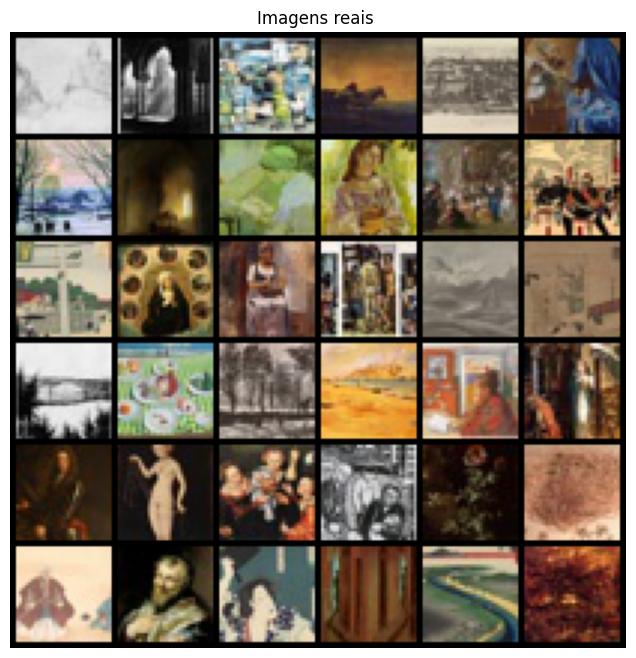

Exemplos de labels:
0: classe=renaissance 
1: classe=surrealism 
2: classe=expressionism 
3: classe=realism 
4: classe=realism 
5: classe=baroque 
6: classe=realism 
7: classe=baroque 
8: classe=post_impressionism 
9: classe=post_impressionism 
10: classe=baroque 
11: classe=ukiyo_e 


In [45]:
x, y, idx = next(iter(train_loader))

grid = make_grid(denorm(x[:36]), nrow=6, padding=2)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.title("Imagens reais ")
plt.show()

print("Exemplos de labels:")
for i in range(min(12, len(y))):
    print(f"{i}: classe={class_names[int(y[i])]} ")

## GAN

https://docs.pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html#what-is-a-gan

### Weight Initialization

In [46]:
# custom weights initialization called on ``netG`` and ``netD``
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


### Generator

In [ ]:
class Generator(nn.Module):
    def __init__(self, ngpu):
        super(Generator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            
            nn.ConvTranspose2d(nz, ngf * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
           
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
            
        )

    def forward(self, input):
        return self.main(input)


In [ ]:

netG = Generator(ngpu).to(DEVIDE)

if (DEVIDE.type == 'cuda') and (ngpu > 1):
    netG = nn.DataParallel(netG, list(range(ngpu)))

netG.apply(weights_init)

print(netG)

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)


### Discriminator

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, ngpu):
        super(Discriminator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
           
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
        
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
            
        )

    def forward(self, input):
        return self.main(input)


In [ ]:
netD = Discriminator(ngpu).to(DEVIDE)

if (DEVIDE.type == 'cuda') and (ngpu > 1):
    netD = nn.DataParallel(netD, list(range(ngpu)))

netD.apply(weights_init)

print(netD)

Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (9): Sigmoid()
  )
)


In [ ]:
criterion = nn.BCELoss()

fixed_noise = torch.randn(64, nz, 1, 1, device=DEVIDE)

real_label = 1.
fake_label = 0.

optimizerD = torch.optim.Adam(netD.parameters(), lr=lr_D, betas=(beta1, 0.999))
optimizerG = torch.optim.Adam(netG.parameters(), lr=lr_G, betas=(beta1, 0.999))

print(f"Learning rates -> G: {lr_G}, D: {lr_D}")
print("Params Gerador :", sum(p.numel() for p in netG.parameters()))
print("Params Discriminador :", sum(p.numel() for p in netD.parameters()))

Learning rates -> G: 0.0002, D: 0.0001
Params Gerador : 1068928
Params Discriminador : 663296


In [52]:
with torch.no_grad():
    z = torch.randn(8, nz, 1, 1, device=DEVIDE)
    fake = netG(z)
    out = netD(fake)

print("Fake batch shape:", fake.shape)
print("Discriminator output shape:", out.shape)

Fake batch shape: torch.Size([8, 3, 32, 32])
Discriminator output shape: torch.Size([8, 1, 1, 1])


In [ ]:
import torchvision.utils as vutils

def train_gan(netG, netD, train_loader, criterion, optimizerG, optimizerD,
              nz, num_epochs, real_label, fake_label, fixed_noise, device):
    img_list = []
    G_losses = []
    D_losses = []
    iters = 0

    print("Starting Training Loop...")
    for epoch in range(num_epochs):
        for i, data in enumerate(train_loader, 0):


            netD.zero_grad()
            real_cpu = data[0].to(device)
            b_size = real_cpu.size(0)
            label = torch.full((b_size,), real_label, dtype=torch.float, device=device)

            output = netD(real_cpu).view(-1)
            errD_real = criterion(output, label)
            
            errD_real=criterion(output, torch.full_like(output, real_label))
            errD_real.backward()
            D_x = output.mean().item()

            noise = torch.randn(b_size, nz, 1, 1, device=device)
            fake = netG(noise)
            label.fill_(fake_label)

            output = netD(fake.detach()).view(-1)
            errD_fake = criterion(output, label)
        
            errD_fake.backward()
            D_G_z1 = output.mean().item()

            errD = errD_real + errD_fake
            optimizerD.step()

            netG.zero_grad()
            label.fill_(real_label)

            output = netD(fake).view(-1)
            errG = criterion(output, label)
            errG.backward()
            D_G_z2 = output.mean().item()
            optimizerG.step()

            if i % 50 == 0:
                print('[%d/%d][%d/%d]\tLoss_D: %.4f\tLoss_G: %.4f\tD(x): %.4f\tD(G(z)): %.4f / %.4f'
                      % (epoch, num_epochs, i, len(train_loader),
                         errD.item(), errG.item(), D_x, D_G_z1, D_G_z2))

            G_losses.append(errG.item())
            D_losses.append(errD.item())

            if (iters % 500 == 0) or ((epoch == num_epochs - 1) and (i == len(train_loader) - 1)):
                with torch.no_grad():
                    fake_fixed = netG(fixed_noise).detach().cpu()
                img_list.append(vutils.make_grid(fake_fixed, padding=2, normalize=True))

            iters += 1

    return G_losses, D_losses, img_list


G_losses, D_losses, img_list = train_gan(
    netG, netD, train_loader, criterion, optimizerG, optimizerD,
    nz, num_epochs, real_label, fake_label, fixed_noise, DEVIDE
)


Starting Training Loop...
[0/50][0/782]	Loss_D: 1.2228	Loss_G: 1.7512	D(x): 0.6255	D(G(z)): 0.4839 / 0.2015
[0/50][50/782]	Loss_D: 0.6775	Loss_G: 3.2830	D(x): 0.7424	D(G(z)): 0.2764 / 0.0464
[0/50][100/782]	Loss_D: 0.3896	Loss_G: 3.9358	D(x): 0.8252	D(G(z)): 0.1302 / 0.0231
[0/50][150/782]	Loss_D: 0.2106	Loss_G: 4.1930	D(x): 0.9251	D(G(z)): 0.1107 / 0.0175
[0/50][200/782]	Loss_D: 0.5378	Loss_G: 2.6234	D(x): 0.7633	D(G(z)): 0.1861 / 0.1053
[0/50][250/782]	Loss_D: 0.7834	Loss_G: 2.1010	D(x): 0.7206	D(G(z)): 0.3301 / 0.1318
[0/50][300/782]	Loss_D: 0.9921	Loss_G: 1.8689	D(x): 0.6198	D(G(z)): 0.3566 / 0.1650
[0/50][350/782]	Loss_D: 0.7111	Loss_G: 3.0664	D(x): 0.7695	D(G(z)): 0.3259 / 0.0563
[0/50][400/782]	Loss_D: 0.8128	Loss_G: 2.9556	D(x): 0.6906	D(G(z)): 0.2911 / 0.0598
[0/50][450/782]	Loss_D: 1.4369	Loss_G: 1.3247	D(x): 0.5403	D(G(z)): 0.4698 / 0.3087
[0/50][500/782]	Loss_D: 0.9548	Loss_G: 1.5654	D(x): 0.6073	D(G(z)): 0.3332 / 0.2237
[0/50][550/782]	Loss_D: 0.8792	Loss_G: 1.4756	D(x): 0

In [54]:
BASE_RESULTS_DIR = PROJECT_ROOT / "gan_dataset_completo"
SEEDS_PLOTS_DIR = BASE_RESULTS_DIR / f"seed_{seed}"
JSONS_DIR = BASE_RESULTS_DIR / "metricas"

SEEDS_PLOTS_DIR.mkdir(parents=True, exist_ok=True)
JSONS_DIR.mkdir(parents=True, exist_ok=True)

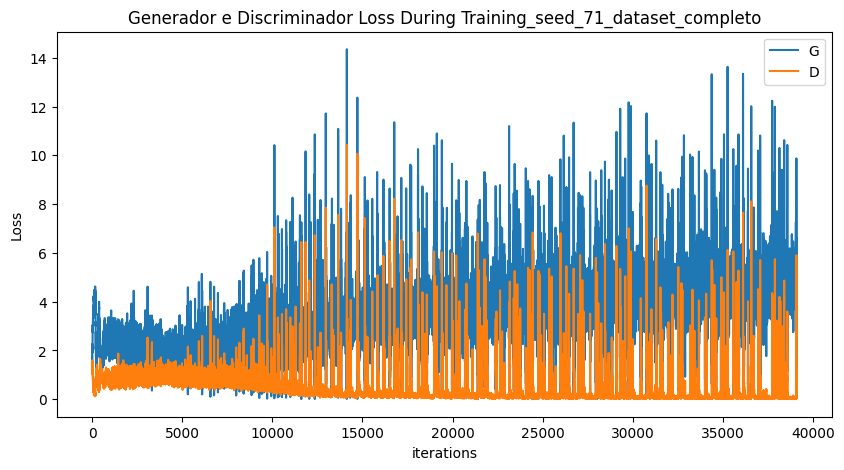

In [ ]:
plt.figure(figsize=(10,5))
plt.title(f"Generador e Discriminador Loss During Training_seed_{seed}_dataset_completo")
plt.plot(G_losses,label="G")
plt.plot(D_losses,label="D")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()

plt.savefig(SEEDS_PLOTS_DIR / f"losses_seed{seed}_dataset_completo.png", dpi=300, bbox_inches="tight")
plt.show()


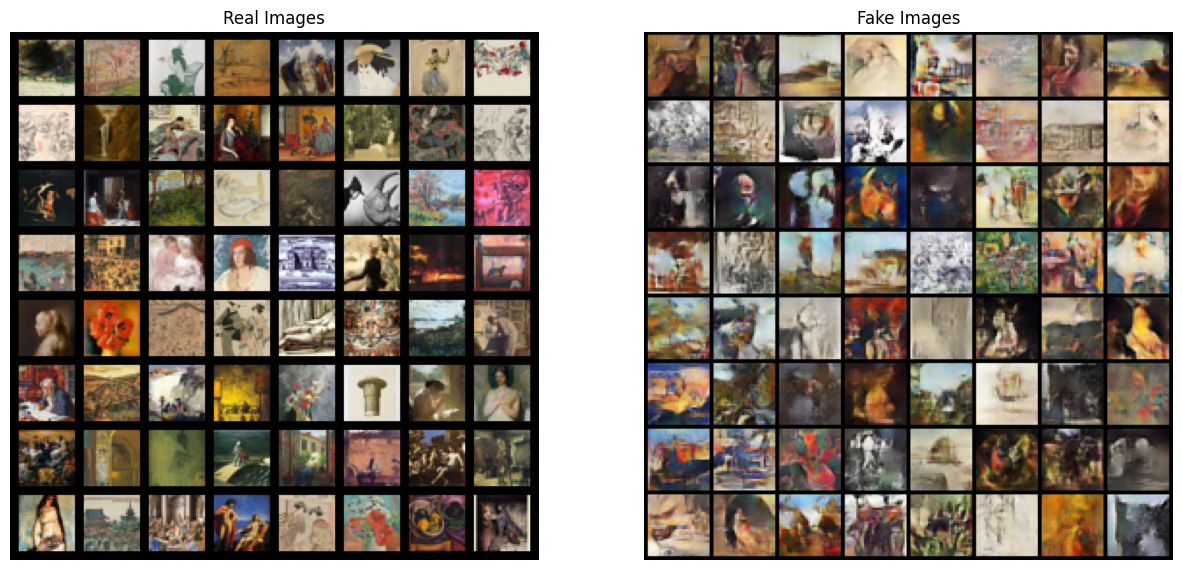

In [ ]:

real_batch = next(iter(train_loader))

plt.figure(figsize=(15,15))
plt.subplot(1,2,1)
plt.axis("off")
plt.title("Real Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(DEVIDE)[:64], padding=5, normalize=True).cpu(),(1,2,0)))

plt.subplot(1,2,2)
plt.axis("off")
plt.title("Fake Images")
plt.imshow(np.transpose(img_list[-1],(1,2,0)))


plt.savefig(SEEDS_PLOTS_DIR / f"real_vs_fake_lsgan_seed_{seed}_dataset_completo.png", dpi=300, bbox_inches="tight")
plt.show()


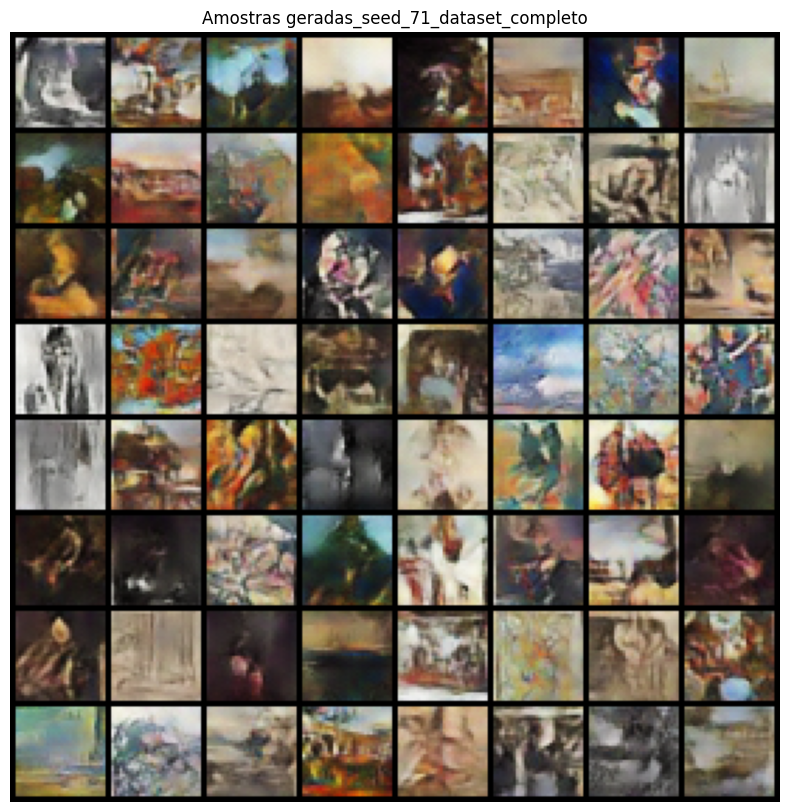

In [ ]:
from pathlib import Path
from torchvision.utils import save_image, make_grid
import matplotlib.pyplot as plt
import torch


netG.eval()
with torch.no_grad():
    noise = torch.randn(64, nz, 1, 1, device=DEVIDE)
    fake_images = netG(noise).cpu()
    fake_images = denorm(fake_images)


grid = make_grid(fake_images, nrow=8) 

save_path = dir_resultados / "grid_dataset_completo.png"
save_image(grid, save_path)

plt.figure(figsize=(10, 10))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title(f"Amostras geradas_seed_{seed}_dataset_completo")
plt.show()

In [ ]:
@torch.no_grad()
def generate_fake_images(generator, n_samples=5000, batch_size=64, latent_dim=100, device="cuda"):
    generator.eval()
    all_images = []

    total = 0
    while total < n_samples:
        current_batch = min(batch_size, n_samples - total)
        z = torch.randn(current_batch, latent_dim, 1, 1, device=device)
        fake = generator(z).cpu()
        fake = denorm(fake)  
        all_images.append(fake)
        total += current_batch

    return torch.cat(all_images, dim=0)

In [ ]:
fake_images = generate_fake_images(netG, n_samples=5000, batch_size=64, latent_dim=nz, device=DEVIDE)
print(fake_images.shape)  

torch.Size([5000, 3, 32, 32])


In [ ]:
@torch.no_grad()
def collect_real_images(dataloader, n_samples=5000):
    all_images = []
    total = 0

    for x, _, _ in dataloader:
        x = denorm(x.cpu())   
        all_images.append(x)
        total += x.size(0)

        if total >= n_samples:
            break

    return torch.cat(all_images, dim=0)[:n_samples]

In [61]:
real_images = collect_real_images(train_loader, n_samples=5000)
print(real_images.shape)

torch.Size([5000, 3, 32, 32])


In [62]:
!pip install torchmetrics[image]

In [ ]:
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance



def to_uint8(x):
    x = (x * 255).clamp(0, 255).to(torch.uint8)
    return x

def compute_fid_kid(real_images, fake_images, device, batch_size=64):
    fid = FrechetInceptionDistance(feature=2048).to(device)
    kid = KernelInceptionDistance(subset_size=100).to(device)

    for start in range(0, len(real_images), batch_size):
        batch = to_uint8(real_images[start:start + batch_size]).to(device)
        fid.update(batch, real=True)
        kid.update(batch, real=True)

    for start in range(0, len(fake_images), batch_size):
        batch = to_uint8(fake_images[start:start + batch_size]).to(device)
        fid.update(batch, real=False)
        kid.update(batch, real=False)

    fid_value = fid.compute().item()
    kid_mean, kid_std = kid.compute()

    return {
        "fid": fid_value,
        "kid_mean": kid_mean.item(),
        "kid_std": kid_std.item()
    }

In [64]:
metrics = compute_fid_kid(real_images, fake_images, DEVIDE)
print(metrics)

{'fid': 54.05027770996094, 'kid_mean': 0.03000662662088871, 'kid_std': 0.0044487230479717255}


In [ ]:


json_path = JSONS_DIR / f"metrics_seed{seed}_datset_completo.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump({
        "seed": seed,
        "metrics": metrics,
        "G_losses": G_losses,
        "D_losses": D_losses,
    }, f, indent=2)
print(f"Metricas guardadas em: {json_path}")

ckpt_g_path = SEEDS_PLOTS_DIR / f"netG_seed{seed}_dataset_completo.pth"
ckpt_d_path = SEEDS_PLOTS_DIR / f"netD_seed{seed}_dataset_completo.pth"
torch.save(netG.state_dict(), ckpt_g_path)
torch.save(netD.state_dict(), ckpt_d_path)


Metricas guardadas em: D:\MESTRADO\1º Ano\2º Semestre\IAG\IAG_TP1\gan_dataset_completo\metricas\metrics_seed71_datset_completo.json


In [ ]:

resultados_dir = PROJECT_ROOT / "gan_dataset_completo" / "metricas"
fids = []
kids = []

for json_file in resultados_dir.glob("metrics_seed*.json"):
    with open(json_file, "r", encoding="utf-8") as f:
        data = json.load(f)
        metrics = data["metrics"]
        fids.append(metrics["fid"])
        kids.append(metrics["kid_mean"])

fids = np.array(fids)
kids = np.array(kids)

print(f"FID: {fids.mean():.2f} ± {fids.std():.2f}")
print(f"KID: {kids.mean():.4f} ± {kids.std():.4f}")

FID: 56.31 ± 1.28
KID: 0.0322 ± 0.0015
